In [18]:
import numpy as np
import pandas as pd
import pyvista as pv
from pathlib import Path
import matplotlib.pyplot as plt

from phd_helpers.AbaqusPostprocessing import(
    get_field_path, get_field_df, add_field_to_mesh, get_history_path, get_deformed_mesh, compute_cartilage_height_change, inp2pv,
    build_tri_tet_mesh
)

In [41]:
DIR = Path('../../../../Computational/InpPipeline/outputs/meshInd/study1')

subject = '50000R'
run_id = '1'
run_id_mesh = '1T'
pose = 'neutral'
job_name = Path(f'{run_id_mesh}-{pose}-{run_id}')

path_inp = DIR / f'inpFiles/{subject}/inp'
path_job = path_inp / job_name
path_csv = path_job / 'resultCSVs'


In [42]:
input_path = path_job / job_name.with_suffix('.inp')

bone = 'tpm'
meshes = inp2pv(input_path)
mesh = meshes[bone]
#mesh = build_tri_tet_mesh(mesh, bone)

In [43]:
# RESULTS

step = 0
frame = -1
instance = f"{bone.upper()}_INST"
metrics = ["CNAREA", "CPRESS", "U"]

# Field data
for metric in metrics:
    field_path = get_field_path(path_csv, metric, step, frame, instance)
    field_df = get_field_df(field_path)
    add_field_to_mesh(mesh, field_df)
mesh['Umag'] = np.linalg.norm(np.column_stack((mesh['U1'], mesh['U2'], mesh['U3'])), axis=1)

# History data
history_data = pd.read_csv(get_history_path(path_csv, step))
history_data = history_data[history_data['historyOutputKey']=='RF1']
# REACTION FORCE - at current frame
RF = np.abs(history_data['value'].iloc[frame])


# DEFORMED MESH
mesh_def = get_deformed_mesh(mesh)
#compute_cartilage_height_change(mesh, mesh_def)
# EXTRACT MESH SURFACES
bone_shell = mesh.extract_cells(mesh[f'{bone}_BONE']==1).extract_surface(algorithm=None)
cartilage_surf = mesh.extract_cells(mesh[f'{bone}_CART_SURF']==1).extract_surface(algorithm=None)

print('Point data: ', mesh.point_data.keys())
print('Cell data: ', mesh.cell_data.keys())

Point data:  ['tpm_PATCH_NODES', 'tpm_PATCH_SURF', 'abaqus_node_id', 'CNAREA', 'CPRESS', 'U3', 'U2', 'U1', 'Umag']
Cell data:  ['tpm_BONE', 'tpm_CARTILAGE', 'tpm_CART_SURF', 'tpm_CART_SURF__FACE_ID', 'abaqus_element_id']


In [10]:
pl = pv.Plotter()
pl.add_mesh(mesh, scalars='CPRESS', cmap='Accent_r')
pl.show()

Widget(value='<iframe src="http://localhost:59712/index.html?ui=P_0x31fe157c0_2&reconnect=auto" class="pyvista…

# Pressure & Contact area

In [62]:
DIR = Path('../../../../Computational/InpPipeline/outputs/meshInd/study1')

bone = 'tpm'
subject = '50000R'
ids = [('0', '1T'), ('1', '1T'), ('0', '2T'), ('1', '2T'), ('0', '3T')]
pose = 'neutral'
step = 0
frame = -1
instance = f"{bone.upper()}_INST"
metrics = ["CNAREA", "CPRESS", "U"]

data = {
    'P0': [],
    'P1': [],
    'A0': [],
    'A1': [],
    'F0': [],
    'F1': [],
    'Nnodes0': [],
    'Nnodes1': []
}
for run_id, run_id_mesh in ids:
    job_name = Path(f'{run_id_mesh}-{pose}-{run_id}')

    path_inp = DIR / f'inpFiles/{subject}/inp'
    path_job = path_inp / job_name
    path_csv = path_job / 'resultCSVs'
    input_path = path_job / job_name.with_suffix('.inp')

    # RESULTS #
    meshes = inp2pv(input_path)
    mesh = meshes[bone]

    # Field data
    for metric in metrics:
        field_path = get_field_path(path_csv, metric, step, frame, instance)
        field_df = get_field_df(field_path)
        add_field_to_mesh(mesh, field_df)
    mesh['Umag'] = np.linalg.norm(np.column_stack((mesh['U1'], mesh['U2'], mesh['U3'])), axis=1)

    # History data
    history_data = pd.read_csv(get_history_path(path_csv, step))
    history_data = history_data[history_data['historyOutputKey']=='RF1']
    # REACTION FORCE - at current frame
    RF = np.abs(history_data['value'].iloc[frame])

    data['P'+run_id].append(mesh['CPRESS'].max())
    data['A'+run_id].append(mesh['CNAREA'].sum())
    data['F'+run_id].append(RF)
    data['Nnodes'+run_id].append(mesh.n_points)

In [51]:
for F in data['F0']+data['F1']:
    print(F)

49.080787658691406
50.02656936645508
49.999507904052734
49.96784973144531
49.98749542236328


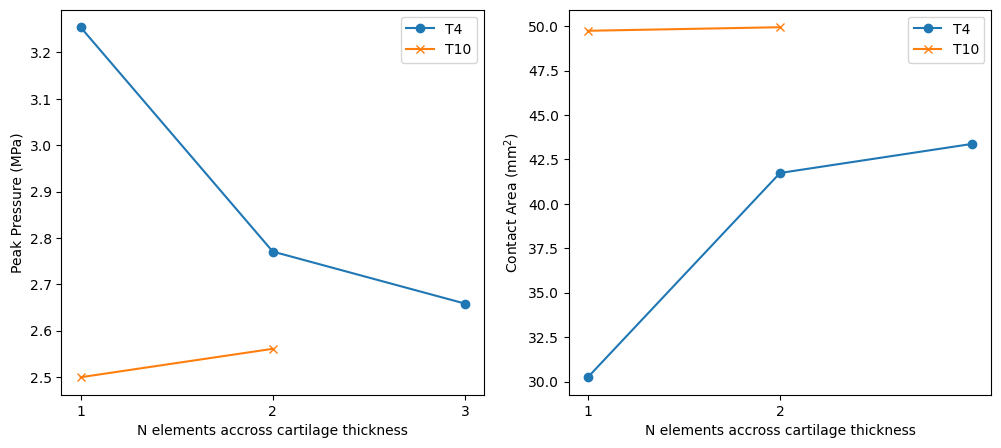

In [59]:
nrows, ncols = 1, 2
fig, ax = plt.subplots(nrows, ncols, figsize=(6*ncols, 5*nrows))

x0 = np.arange(1, 4) 
x1 = np.arange(1, 3)

ax[0].plot(x0, data['P0'], marker='o', label='T4')
ax[0].plot(x1, data['P1'], marker='x', label='T10')

ax[0].set_ylabel('Peak Pressure (MPa)')
ax[0].set_xlabel('N elements accross cartilage thickness')

ax[1].plot(x0, data['A0'], marker='o', label='T4')
ax[1].plot(x1, data['A1'], marker='x', label='T10')

ax[1].set_ylabel('Contact Area (mm$^2$)')
ax[1].set_xlabel('N elements accross cartilage thickness')

ax[0].set_xticks(x0)
ax[1].set_xticks(x1)
for ax_i in ax:
    ax_i.legend()
plt.show()

In [60]:
data

{'P0': [np.float64(3.2541959285736084),
  np.float64(2.7705116271972656),
  np.float64(2.6584062576293945)],
 'P1': [np.float64(2.499643325805664), np.float64(2.5608880519866943)],
 'A0': [np.float64(30.24356700759381),
  np.float64(41.737430680484934),
  np.float64(43.375084502724235)],
 'A1': [np.float64(49.74020758144611), np.float64(49.940180435896565)],
 'F0': [np.float64(49.080787658691406),
  np.float64(50.02656936645508),
  np.float64(49.999507904052734)],
 'F1': [np.float64(49.96784973144531), np.float64(49.98749542236328)]}